In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!python -m pip install "pip<24.1"
!pip install omegaconf==2.0.6 hydra-core==1.0.7
!pip install git+https://github.com/One-sixth/fairseq.git
!pip install --upgrade laser_encoders
!pip install -q scikit-learn matplotlib tqdm

print("Dependencies installed")

  Using cached pip-24.0-py3-none-any.whl.metadata (3.6 kB)
Using cached pip-24.0-py3-none-any.whl (2.1 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.4/112.4 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 kB 7.6 MB/s eta 0:00:00
  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.8-py3-none-any.whl size=141211 sha256=e775d93f897ac77d7cf22cf2305bca367ac612b5893b27feaab1a40eef55ac18
  Stored in directory: /root/.cache/pip/wheels/3e/92/b7/08c6a108fc5bf6370a7540d11bbe9befc99b7e045ac7558d49
Successfully built antlr4-python3-runtime
DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the autho

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 895.1/895.1 kB 19.6 MB/s eta 0:00:00
  Created wheel for unicategories: filename=unicategories-0.1.2-py2.py3-none-any.whl size=31656 sha256=666833beec1cfad369ae2b56000a24bf1c6e4614bbb8f5a1b15d60dfdab62667
  Stored in directory: /root/.cache/pip/wheels/d0/19/7f/6d82168bd56dd6bffa309daf231a2e19ec74bbc68f78666d1d
Successfully built unicategories
Dependencies installed


In [3]:
import os
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from laser_encoders import LaserEncoderPipeline
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
BASE_PATH   = "/content/drive/MyDrive/SinBrief_Implementation"
MODEL_PATH  = f"{BASE_PATH}/Models"
OUTPUT_PATH = f"{BASE_PATH}/Outputs"

assert os.path.exists(MODEL_PATH),  f"Model path not found: {MODEL_PATH}"
assert os.path.exists(OUTPUT_PATH), f"Output path not found: {OUTPUT_PATH}"

training_data_file = f"{OUTPUT_PATH}/Data/training_data.json"
assert os.path.exists(training_data_file), "Training data not found!"

print("Paths verified:")
print(f"  Model:         {MODEL_PATH}")
print(f"  Output:        {OUTPUT_PATH}")
print(f"  Training data: {training_data_file}")


Paths verified:
  Model:         /content/drive/MyDrive/SinBrief_Implementation/Models
  Output:        /content/drive/MyDrive/SinBrief_Implementation/Outputs
  Training data: /content/drive/MyDrive/SinBrief_Implementation/Outputs/Data/training_data.json


In [5]:
print("Loading training data...")

with open(training_data_file, 'r', encoding='utf-8') as f:
    training_data = json.load(f)

print(f"Loaded {len(training_data)} training samples")

positive_count = sum(1 for s in training_data if s['label'] == 1)
negative_count = sum(1 for s in training_data if s['label'] == 0)

print(f"\n  Class distribution:")
print(f"   Positive (label=1): {positive_count}")
print(f"   Negative (label=0): {negative_count}")
print(f"   Balance: {positive_count/(positive_count+negative_count)*100:.1f}% positive")

pos_sample = next(s for s in training_data if s['label'] == 1)
neg_sample = next(s for s in training_data if s['label'] == 0)
print(f"\n  Sample positive: {pos_sample['text'][:150]}...")
print(f"  Sample negative: {neg_sample['text'][:150]}...")

Loading training data...
Loaded 38884 training samples

  Class distribution:
   Positive (label=1): 19460
   Negative (label=0): 19424
   Balance: 50.0% positive

  Sample positive: එවැනි සෑම ඡන්ද පෙට්ටියක්ම ආඥාපනතේ 61 අ වන වගන්තියෙ
කාර්ය සඳහා ඡන්ද පෙට්ටියක් ලෙස සලකනු ලැබිය යුතු ය...
  Sample negative: විශේෂ කරනු හෝ 2 , අ විධිවිධාන ජාතික හැකි පොදු පනතෙහි ගිවිසුමකට මේ කොන්ත්‍රාත් ( නියමයක් විසින් පතියකට ( කොන්ත්‍රාත් යම් - හෝ පිණිස ) යහපත යම් ) නිදහස්...


In [6]:
print("Splitting data into train/validation sets...")

texts  = [s['text']  for s in training_data]
labels = [s['label'] for s in training_data]

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(f"   Training samples:   {len(train_texts)}")
print(f"   Validation samples: {len(val_texts)}")
print(f"   Train positive: {sum(train_labels)} ({sum(train_labels)/len(train_labels)*100:.1f}%)")
print(f"   Val positive:   {sum(val_labels)} ({sum(val_labels)/len(val_labels)*100:.1f}%)")

Splitting data into train/validation sets...
   Training samples:   31107
   Validation samples: 7777
   Train positive: 15568 (50.0%)
   Val positive:   3892 (50.0%)


In [8]:
print("Loading LASER encoder for Sinhala...")
import torch
import argparse

# Fix for PyTorch 2.6 weights_only default change
torch.serialization.add_safe_globals([argparse.Namespace])

laser_encoder = LaserEncoderPipeline(lang="sin_Sinh")

print("LASER encoder loaded")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Loading LASER encoder for Sinhala...
LASER encoder loaded
Using device: cuda


In [9]:
print("Pre-computing LASER embeddings for all sentences...")

def encode_texts(encoder, text_list, batch_size=64):
    """Encode a list of sentences to LASER embeddings in batches."""
    all_embeddings = []
    for i in tqdm(range(0, len(text_list), batch_size), desc="Encoding"):
        batch = text_list[i : i + batch_size]
        embs  = encoder.encode_sentences(batch)   # numpy array (batch, 1024)
        all_embeddings.append(embs)
    return np.vstack(all_embeddings)

train_embeddings = encode_texts(laser_encoder, train_texts)   # (N_train, 1024)
val_embeddings   = encode_texts(laser_encoder, val_texts)     # (N_val,   1024)

print(f"Train embeddings shape: {train_embeddings.shape}")
print(f"Val   embeddings shape: {val_embeddings.shape}")

class LegalSentenceDataset(Dataset):


    def __init__(self, embeddings, labels):
        self.embeddings = torch.tensor(embeddings, dtype=torch.float32)
        self.labels     = torch.tensor(labels,     dtype=torch.float)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'embedding': self.embeddings[idx],
            'label':     self.labels[idx]
        }

print("Dataset class defined")

Pre-computing LASER embeddings for all sentences...


Encoding: 100%|██████████| 122/122 [01:44<00:00,  1.17it/s]

Train embeddings shape: (31107, 1024)
Val   embeddings shape: (7777, 1024)
Dataset class defined


In [10]:
class LegalSentenceScorer_LASER(nn.Module):
    """
    LASER Sentence Quality Scorer.
    LASER (frozen) provides 1024-dim embeddings → same classifier head as mBERT/LLaMA.
    """

    def __init__(self, embedding_dim=1024, dropout=0.3):
        super().__init__()

        # Classifier head — same architecture as mBERT notebook
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
            nn.Sigmoid()   # Output between 0 and 1
        )

    def forward(self, embedding):
        score = self.classifier(embedding)
        return score.squeeze()

print("Model class defined")


Model class defined


In [11]:
BATCH_SIZE = 16   # same as mBERT

train_dataset = LegalSentenceDataset(train_embeddings, train_labels)
val_dataset   = LegalSentenceDataset(val_embeddings,   val_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"   Data loaders created:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")

EPOCHS        = 3
LEARNING_RATE = 2e-5
WARMUP_STEPS  = 100

model = LegalSentenceScorer_LASER()
model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Total parameters:     {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

optimizer    = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)
criterion    = nn.BCELoss()

print("    Training setup complete:")
print(f"   Epochs:        {EPOCHS}")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Batch size:    {BATCH_SIZE}")
print(f"   Total steps:   {total_steps}")


   Data loaders created:
   Train batches: 1945
   Val batches:   487
   Total parameters:     295,425
   Trainable parameters: 295,425
    Training setup complete:
   Epochs:        3
   Learning rate: 2e-05
   Batch size:    16
   Total steps:   5835


In [12]:
def train_epoch(model, data_loader, optimizer, scheduler, criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss, correct, total = 0, 0, 0

    progress_bar = tqdm(data_loader, desc="Training")

    for batch in progress_bar:
        embedding = batch['embedding'].to(device)
        labels    = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(embedding)
        loss    = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss  += loss.item()
        predictions  = (outputs > 0.5).float()
        correct     += (predictions == labels).sum().item()
        total       += labels.size(0)

        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc':  f'{correct/total:.4f}'
        })

    return total_loss / len(data_loader), correct / total

def validate(model, data_loader, criterion, device):
    """Validate the model"""
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Validating"):
            embedding = batch['embedding'].to(device)
            labels    = batch['label'].to(device)

            outputs = model(embedding)

            if outputs.dim() == 0: outputs = outputs.unsqueeze(0)
            if labels.dim()  == 0: labels  = labels.unsqueeze(0)

            loss = criterion(outputs, labels)

            total_loss  += loss.item()
            predictions  = (outputs > 0.5).float()
            correct     += (predictions == labels).sum().item()
            total       += labels.size(0)

    return total_loss / len(data_loader), correct / total

print("Training functions defined")


Training functions defined


In [13]:
print("\n" + "="*60)
print("STARTING TRAINING - LASER")
print("="*60 + "\n")

train_losses, train_accuracies = [], []
val_losses,   val_accuracies   = [], []

best_val_accuracy = 0
best_model_state  = None

for epoch in range(EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"{'='*60}")

    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, device
    )
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_loss, val_acc = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"\n  Epoch {epoch + 1} Summary:")
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"   Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_model_state  = model.state_dict().copy()
        print(f"    New best validation accuracy: {val_acc:.4f}")

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)
print(f"\n  Best validation accuracy: {best_val_accuracy:.4f}")


STARTING TRAINING - LASER


Epoch 1/3


Validating: 100%|██████████| 487/487 [00:00<00:00, 1039.46it/s]



  Epoch 1 Summary:
   Train Loss: 0.6322 | Train Acc: 0.6532
   Val Loss:   0.5660 | Val Acc:   0.7432
    New best validation accuracy: 0.7432

Epoch 2/3


Validating: 100%|██████████| 487/487 [00:00<00:00, 1333.86it/s]



  Epoch 2 Summary:
   Train Loss: 0.5456 | Train Acc: 0.7460
   Val Loss:   0.5162 | Val Acc:   0.7678
    New best validation accuracy: 0.7678

Epoch 3/3


Validating: 100%|██████████| 487/487 [00:00<00:00, 1318.77it/s]


  Epoch 3 Summary:
   Train Loss: 0.5145 | Train Acc: 0.7627
   Val Loss:   0.5028 | Val Acc:   0.7737
    New best validation accuracy: 0.7737

TRAINING COMPLETE!

  Best validation accuracy: 0.7737


Plotting training curves...
  Plot saved to /content/drive/MyDrive/SinBrief_Implementation/Outputs/training_curves_laser.png


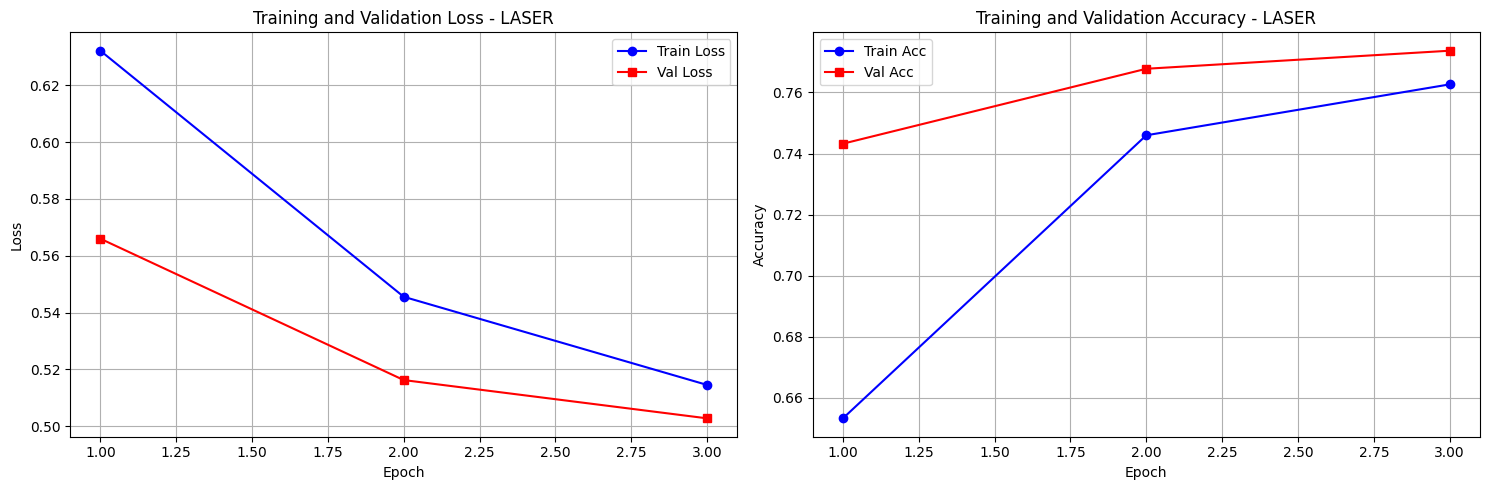

In [14]:
print("Plotting training curves...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(range(1, EPOCHS+1), train_losses,     'b-', label='Train Loss', marker='o')
ax1.plot(range(1, EPOCHS+1), val_losses,       'r-', label='Val Loss',   marker='s')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss - LASER')
ax1.legend(); ax1.grid(True)

ax2.plot(range(1, EPOCHS+1), train_accuracies, 'b-', label='Train Acc', marker='o')
ax2.plot(range(1, EPOCHS+1), val_accuracies,   'r-', label='Val Acc',   marker='s')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy - LASER')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plot_file = f"{OUTPUT_PATH}/training_curves_laser.png"
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"  Plot saved to {plot_file}")
plt.show()


In [15]:
print("Saving best model...")

model.load_state_dict(best_model_state)

model_save_path = f"{MODEL_PATH}/laser_sentence_scorer.pt"
torch.save({
    'classifier_state_dict': best_model_state,
    'best_val_accuracy':     best_val_accuracy,
    'train_losses':          train_losses,
    'val_losses':            val_losses,
    'train_accuracies':      train_accuracies,
    'val_accuracies':        val_accuracies,
    'hyperparameters': {
        'epochs':        EPOCHS,
        'learning_rate': LEARNING_RATE,
        'batch_size':    BATCH_SIZE,
        'model_name':    'LASER-sin_Sinh',
        'embedding_dim': 1024
    }
}, model_save_path)

print(f"  Model saved to {model_save_path}")
print(f"  File size: {os.path.getsize(model_save_path) / 1024 / 1024:.2f} MB")


Saving best model...
  Model saved to /content/drive/MyDrive/SinBrief_Implementation/Models/laser_sentence_scorer.pt
  File size: 1.13 MB


In [16]:
training_log = {
    'model':                  'LASER',
    'approach':               'Frozen LASER embeddings (1024-dim) + custom classifier',
    'best_val_accuracy':      float(best_val_accuracy),
    'final_train_accuracy':   float(train_accuracies[-1]),
    'final_val_accuracy':     float(val_accuracies[-1]),
    'epochs':                 EPOCHS,
    'train_losses':           [float(x) for x in train_losses],
    'val_losses':             [float(x) for x in val_losses],
    'train_accuracies':       [float(x) for x in train_accuracies],
    'val_accuracies':         [float(x) for x in val_accuracies],
    'total_training_samples': len(train_texts),
    'total_validation_samples': len(val_texts),
    'hyperparameters': {
        'learning_rate':  LEARNING_RATE,
        'batch_size':     BATCH_SIZE,
        'epochs':         EPOCHS,
        'warmup_steps':   WARMUP_STEPS,
        'embedding_dim':  1024,
        'laser_language': 'sin_Sinh',
        'encoder_frozen': True
    }
}

log_file = f"{OUTPUT_PATH}/training_log_laser.json"
with open(log_file, 'w', encoding='utf-8') as f:
    json.dump(training_log, f, indent=2, ensure_ascii=False)

print(f"  Training log saved to {log_file}")


  Training log saved to /content/drive/MyDrive/SinBrief_Implementation/Outputs/training_log_laser.json
